In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import re
from collections import defaultdict
from collections import Counter
from mlxtend.frequent_patterns import apriori, association_rules
import warnings
warnings.filterwarnings('ignore')


In [2]:
df = pd.read_csv('Groceries_dataset.csv')

print("Sample data:")
print(df.head())

print("\nInfo:")
print(df.info())

Sample data:
   Member_number        Date   itemDescription
0           1808  21-07-2015    tropical fruit
1           2552  05-01-2015        whole milk
2           2300  19-09-2015         pip fruit
3           1187  12-12-2015  other vegetables
4           3037  01-02-2015        whole milk

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38765 entries, 0 to 38764
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Member_number    38765 non-null  int64 
 1   Date             38765 non-null  object
 2   itemDescription  38765 non-null  object
dtypes: int64(1), object(2)
memory usage: 908.7+ KB
None


## 1.1

In [3]:
# Check missing values
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percent': missing_percent
})
print("\nMissing values in each column:")
print(missing_df)


# Check duplicated transactions
duplicate_transactions = df.duplicated(subset=['Member_number', 'Date', 'itemDescription']).sum()
print(f"Number of duplicate transactions: {duplicate_transactions}")

if duplicate_transactions > 0:
    print("Sample of duplicate records:")
    dup_samples = df[df.duplicated(subset=['Member_number', 'Date', 'itemDescription'], keep=False)].head(10)
    print(dup_samples)


# Check for outliers
member_transaction_count = df.groupby('Member_number').size()
print(f"\nStatistics of transactions per customer:")
print(member_transaction_count.describe())

# Detect outliers using IQR method for transaction count
Q1 = member_transaction_count.quantile(0.25)
Q3 = member_transaction_count.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outlier_members = member_transaction_count[(member_transaction_count < lower_bound) | (member_transaction_count > upper_bound)]
print(f"\nNumber of customers with outlier transaction count: {len(outlier_members)}")
print("Sample of these customers:")
print(outlier_members.head(10))

# Check invalid dates
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y', errors='coerce')
invalid_dates = df['Date'].isnull().sum()
print(f"\nNumber of invalid dates: {invalid_dates}")

# Date range
if invalid_dates == 0:
    print(f"Date range: from {df['Date'].min()} to {df['Date'].max()}")

# Check item description length (unusually short or long)
item_lengths = df['itemDescription'].str.len()
print(f"\nStatistics of item description length:")
print(item_lengths.describe())

unusual_items = df[(item_lengths < 2) | (item_lengths > 30)]
if not unusual_items.empty:
    print("\nItems with unusual string length:")
    print(unusual_items[['itemDescription']].drop_duplicates())



Missing values in each column:
                 Missing Count  Missing Percent
Member_number                0              0.0
Date                         0              0.0
itemDescription              0              0.0
Number of duplicate transactions: 759
Sample of duplicate records:
     Member_number        Date  itemDescription
63            1663  07-02-2015       rolls/buns
98            3645  12-12-2015     citrus fruit
129           3779  15-09-2015      frankfurter
213           3812  21-07-2015          sausage
216           1344  04-09-2015    bottled water
256           2353  02-05-2015             soda
309           4899  12-03-2015          chicken
353           3929  28-04-2015  root vegetables
375           3967  23-11-2015       whole milk
437           2435  17-07-2015           onions

Statistics of transactions per customer:
count    3898.000000
mean        9.944844
std         5.310796
min         2.000000
25%         6.000000
50%         9.000000
75%        13

## 1.2

Total number of unique items: 167
Total number of transactions: 38765
Average transactions per item: 232.13

Sample of unique items:
  1. Instant food products
  2. UHT-milk
  3. abrasive cleaner
  4. artif. sweetener
  5. baby cosmetics
  6. bags
  7. baking powder
  8. bathroom cleaner
  9. beef
 10. berries
 11. beverages
 12. bottled beer
 13. bottled water
 14. brandy
 15. brown bread
 16. butter
 17. butter milk
 18. cake bar
 19. candles
 20. candy

Frequency statistics:
count     167.000000
mean      232.125749
std       363.442098
min         1.000000
25%        30.500000
50%        85.000000
75%       264.000000
max      2502.000000
Name: count, dtype: float64

Top 50 most frequent items:
itemDescription
whole milk                  2502
other vegetables            1898
rolls/buns                  1716
soda                        1514
yogurt                      1334
root vegetables             1071
tropical fruit              1032
bottled water                933
sausage     

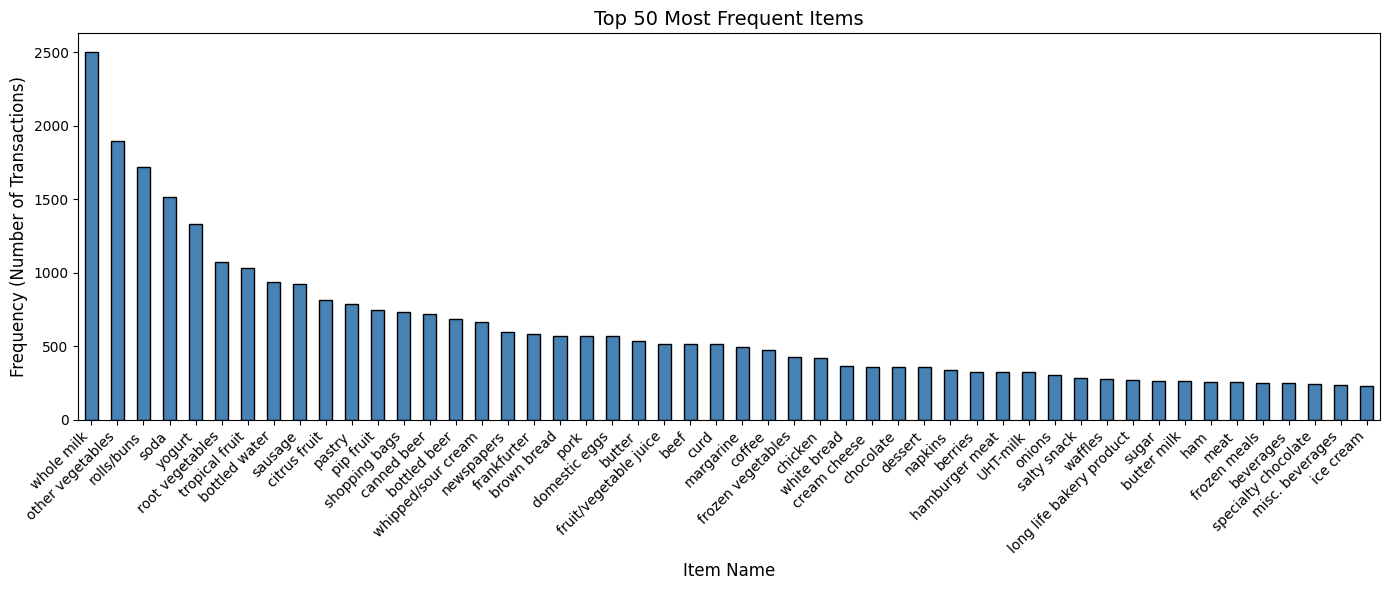

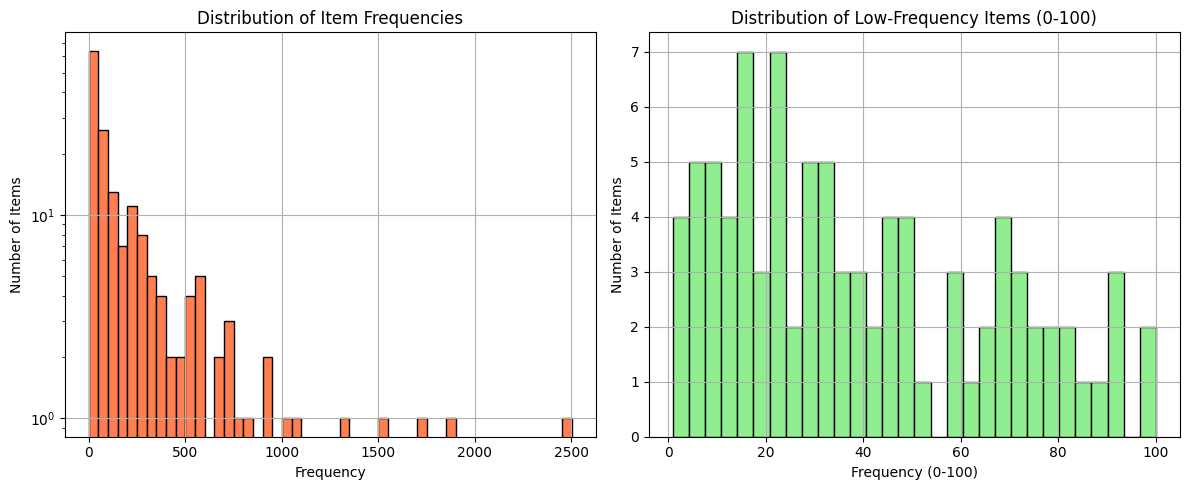

In [4]:
# Unique items
unique_items = df['itemDescription'].unique()
print(f"Total number of unique items: {len(unique_items)}")
print(f"Total number of transactions: {len(df)}")
print(f"Average transactions per item: {len(df) / len(unique_items):.2f}")

print("\nSample of unique items:")
for i, item in enumerate(sorted(unique_items)[:20], 1):
    print(f"{i:3}. {item}")



# Calculate frequency of each item
item_freq = df['itemDescription'].value_counts()
item_freq_df = pd.DataFrame({
    'Item': item_freq.index,
    'Frequency': item_freq.values,
    'Percentage': (item_freq.values / len(df) * 100).round(2)
})

print(f"\nFrequency statistics:")
print(item_freq.describe())


TOP_N = 50                   # Number of top items to display
MIN_FREQUENCY = 50             
HIGH_FREQUENCY=1000            # Threshold for high-frequency items


top_items = item_freq.head(TOP_N)
print(f"\nTop {TOP_N} most frequent items:")
print(top_items.to_string())

# Items with frequency >= MIN_FREQUENCY
frequent_items = item_freq[item_freq >= MIN_FREQUENCY]
print(f"\nItems with frequency >= {MIN_FREQUENCY}:")
print(f"Count: {len(frequent_items)}")
print(f"Top 10 of these items:")
print(frequent_items.head(10).to_string())

# Items with frequency >= HIGH_FREQUENCY
high_freq_items = item_freq[item_freq >= HIGH_FREQUENCY]
print(f"\nItems with frequency >= {HIGH_FREQUENCY}:")
print(f"Count: {len(high_freq_items)}")
print(high_freq_items.to_string())


# Items that appear only once
single_purchase_items = item_freq[item_freq == 1]
print(f"\nItems purchased only once (Rare items):")
print(f"Count: {len(single_purchase_items)}")
print(f"Percentage of unique items: {len(single_purchase_items) / len(unique_items) * 100:.2f}%")
print(f"Sample:")
print(single_purchase_items.head(10).to_string())


# Calculate cumulative percentage of transactions covered by top items
item_freq_sorted = item_freq.sort_values(ascending=False)
cumulative_sum = item_freq_sorted.cumsum()
cumulative_percent = (cumulative_sum / len(df)) * 100

# Find how many items cover 80% of transactions
items_for_80_percent = (cumulative_percent <= 80).sum() + 1
print(f"\nNumber of items that cover 80% of all transactions: {items_for_80_percent}")
print(f"Top {items_for_80_percent} items cover 80% of transactions")
print(f"These represent {items_for_80_percent / len(unique_items) * 100:.2f}% of all unique items")


# Frequency distribution
bins = [0, 1, 5, 10, 20, 50, 100, 200, 500, 1000, float('inf')]
labels = ['1', '2-5', '6-10', '11-20', '21-50', '51-100', '101-200', '201-500', '501-1000', '1000+']
item_freq_binned = pd.cut(item_freq, bins=bins, labels=labels, right=False)
freq_dist = item_freq_binned.value_counts().sort_index()

print("\nFrequency distribution of items:")
print(freq_dist.to_string())


# Top 20 items
plt.figure(figsize=(14, 6))
top_items.plot(kind='bar', edgecolor='black', color='steelblue')
plt.xlabel('Item Name', fontsize=12)
plt.ylabel('Frequency (Number of Transactions)', fontsize=12)
plt.title(f'Top {TOP_N} Most Frequent Items', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.tight_layout()
plt.show()

# Frequency distribution histogram
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
item_freq.hist(bins=50, edgecolor='black', color='coral')
plt.xlabel('Frequency')
plt.ylabel('Number of Items')
plt.title('Distribution of Item Frequencies')
plt.yscale('log')

plt.subplot(1, 2, 2)
item_freq[item_freq <= 100].hist(bins=30, edgecolor='black', color='lightgreen')
plt.xlabel('Frequency (0-100)')
plt.ylabel('Number of Items')
plt.title('Distribution of Low-Frequency Items (0-100)')

plt.tight_layout()
plt.show()

## 1.3

In [5]:
print(f"\nTotal records before cleaning: {len(df)}")
print(f"Unique items before cleaning: {df['itemDescription'].nunique()}")


# Convert to lowercase
items_lower = df['itemDescription'].str.lower().str.strip()
item_groups = defaultdict(set)

for original, normalized in zip(df['itemDescription'], items_lower):
    item_groups[normalized].add(original)

# Find items that have multiple representations
variations = {normalized: list(representations) 
              for normalized, representations in item_groups.items() 
              if len(representations) > 1}

print(f"\nNumber of items with case/whitespace variations: {len(variations)}")

if variations:
    print("\nSample of variations found:")
    for i, (normalized, reps) in enumerate(list(variations.items())[:5], 1):
        print(f"\n{i}. Normalized: '{normalized}'")
        print(f"   Variations found: {reps}")
else:
    print("No variations found!")

# Check for leading/trailing whitespaces
items_with_whitespace = df[df['itemDescription'].str.strip() != df['itemDescription']]
print(f"\nItems with leading/trailing whitespace: {len(items_with_whitespace)}")

if len(items_with_whitespace) > 0:
    print("Sample of items with whitespace issues:")
    print(items_with_whitespace['itemDescription'].unique()[:5])

# Check for multiple spaces between words
def has_multiple_spaces(text):
    return bool(re.search(r'\s{2,}', text))

items_with_multiple_spaces = df[df['itemDescription'].apply(has_multiple_spaces)]
print(f"\nItems with multiple spaces: {len(items_with_multiple_spaces)}")

if len(items_with_multiple_spaces) > 0:
    print("Sample of items with multiple spaces:")
    print(items_with_multiple_spaces['itemDescription'].unique()[:5])



def standardize_item(text): # This function Standardizes items' names. (Strip leading/trailing whitespace, Remove multiple spaces, Convert to lowercase, Capitalize first letter of each word)

    if not isinstance(text, str):
        return text
    
    # Strip whitespace
    text = text.strip()
    
    # Remove multiple spaces
    text = re.sub(r'\s+', ' ', text)
    
    # Convert to lowercase
    text = text.lower()
    
    # Capitalize first letter of each word
    text = text.title()
    
    return text


df['itemDescription_standardized'] = df['itemDescription'].apply(standardize_item)


# Show changes for items that had variations
if variations:
    print("\nExample of standardization (items with variations):")
    for normalized, reps in list(variations.items())[:10]:
        standardized = standardize_item(normalized)
        print(f"\nOriginal variations: {reps}")
        print(f"Standardized to: '{standardized}'")
else:
    # If no variations, show random sample
    sample_items = df['itemDescription'].sample(10).tolist()
    print("\nSample standardization:")
    for item in sample_items:
        standardized = standardize_item(item)
        print(f"Before: '{item}' -> After: '{standardized}'")

# Compare unique counts
print(f"\nUnique items BEFORE standardization: {df['itemDescription'].nunique()}")
print(f"Unique items AFTER standardization: {df['itemDescription_standardized'].nunique()}")

reduction = df['itemDescription'].nunique() - df['itemDescription_standardized'].nunique()
print(f"Reduction in unique items: {reduction}")


# Replace original column with standardized version
df['itemDescription'] = df['itemDescription_standardized']
df = df.drop('itemDescription_standardized', axis=1)



Total records before cleaning: 38765
Unique items before cleaning: 167

Number of items with case/whitespace variations: 0
No variations found!

Items with leading/trailing whitespace: 440
Sample of items with whitespace issues:
['cream cheese ' 'roll products ']

Items with multiple spaces: 0

Sample standardization:
Before: 'butter' -> After: 'Butter'
Before: 'whole milk' -> After: 'Whole Milk'
Before: 'UHT-milk' -> After: 'Uht-Milk'
Before: 'soda' -> After: 'Soda'
Before: 'long life bakery product' -> After: 'Long Life Bakery Product'
Before: 'pip fruit' -> After: 'Pip Fruit'
Before: 'whole milk' -> After: 'Whole Milk'
Before: 'whipped/sour cream' -> After: 'Whipped/Sour Cream'
Before: 'root vegetables' -> After: 'Root Vegetables'
Before: 'shopping bags' -> After: 'Shopping Bags'

Unique items BEFORE standardization: 167
Unique items AFTER standardization: 167
Reduction in unique items: 0


According to the above results, in the dataset, a product is always written in the same way, and a product is not counted twice due to different writing, but the extra space characters from the beginning and end of the names of some products were removed.

## 1.5

In [6]:
# Group by customer and date to create baskets
baskets = df.groupby(['Member_number', 'Date'])['itemDescription'].apply(list).reset_index()
baskets['basket_size'] = baskets['itemDescription'].apply(len)

# Identify single-item transactions
single_item_baskets = baskets[baskets['basket_size'] == 1]
multi_item_baskets = baskets[baskets['basket_size'] > 1]

print(f"\nTotal baskets: {len(baskets)}")
print(f"Single-item baskets: {len(single_item_baskets)} ({len(single_item_baskets)/len(baskets)*100:.2f}%)")
print(f"Multi-item baskets: {len(multi_item_baskets)} ({len(multi_item_baskets)/len(baskets)*100:.2f}%)")


Total baskets: 14963
Single-item baskets: 0 (0.00%)
Multi-item baskets: 14963 (100.00%)


In this dataset, our analysis revealed that there are no single-item transactions – every shopping basket contains at least two items.So we did not need to perform the comparative analysis of association rules with and without single-item transactions, as both scenarios would yield identical results. But we can analyze mathematical impact of single-item shopping baskets on Confidence score:

## The Mathematical Impact of Single-Item Transactions on Confidence

We know:

$$Confidence(A \rightarrow B) = \frac{Support(A \cup B)}{Support(A)} = \frac{P(A \cap B)}{P(A)}$$


When we have single-item transactions in our dataset, they affect the confidence calculation in the below  way:

- **Support(A ∪ B)**: This represents the number of transactions containing **both** items A and B. Single-item transactions **never** contribute to this value because they contain only one item.

- **Support(A)**: This represents the number of transactions containing item A. Single-item transactions **do** contribute to this value because they contain item A alone.


When single-item transactions exist in the dataset, the denominator increases while the numerator stays constant. This mathematically guarantees that confidence will decrease:


### Example

 A dataset with the following transactions:

| Transaction | Items Purchased |
|-------------|-----------------|
| 1 | Milk, Bread |
| 2 | Milk, Bread |
| 3 | Milk |
| 4 | Milk |
| 5 | Bread |

**With Single-Item Transactions:**

$$Support(Milk) = \frac{4}{5} = 0.80$$

$$Support(Milk \cap Bread) = \frac{2}{5} = 0.40$$

$$Confidence = \frac{0.40}{0.80} = \mathbf{0.50}$$

**Without Single-Item Transactions (removing transactions 3, 4, and 5):**

$$Support(Milk) = \frac{2}{2} = 1.00$$

$$Support(Milk \cap Bread) = \frac{2}{2} = 1.00$$

$$Confidence = \frac{1.00}{1.00} = \mathbf{1.00}$$

 Confidence increased from 50% to 100% after removing single-item transactions.



## Removing Single-Item Transactions is Standard Practice:

In real-world data science projects, single-item transactions are almost removed before performing association rule mining.Because:

### 1. The Denominator Effect

Single-item transactions act as **"noise"** in the confidence calculation. They increase the denominator of the confidence formula without providing any information about item combinations. This artificially lowers the confidence values of rules that would otherwise appear stronger. The effect is particularly pronounced for items that are frequently purchased alone, such as staple products like milk or bread.

### 2. Focus on Purchase Patterns

Association rule mining aims to discover **combinations** of items that are frequently purchased together. Single-item purchases provide absolutely no information about item relationships or co-occurrence patterns. By removing them, we focus our analysis on the transactions that actually contain the information we're trying to discover.

### 3. Higher Quality Rules

Removing single-item transactions yields rules with higher confidence, making them more reliable for business decisions. This is especially important when the rules will be used in production systems like recommendation engines.




## When to Keep Single-Item Transactions

Despite the general recommendation to remove them, there are scenarios where keeping single-item transactions is appropriate:

### 1. Product Popularity Analysis

Single-item purchases are valuable for understanding which products are bought alone. This information can be useful for inventory management, promotion planning, and understanding customer behavior.

### 2. Customer Segmentation

Customers who make only single-item purchases may represent a distinct segment with different needs and behaviors. Understanding this segment can inform targeted marketing strategies.

### 3. Impulse Buy Analysis

Single-item transactions might represent unplanned purchases. Analyzing these transactions can provide insights into impulse buying behavior.

### 4. Low Percentage Scenario

If single-item transactions represent less than 5% of total transactions, their impact on confidence is minimal and may not justify the effort of removing them. In such cases, the choice becomes a matter of personal preference or project requirements.